# СМВУ: от журнала событий к прогнозу отказов

Две модели оценивают, появится ли **новый эпизод тревожного «Неисправен»** у конкретного канала «Состояние вентилятора» или «Состояние насоса» через 1–30 суток после даты прогноза. Это прогноз журнальной тревоги, а не подтверждённого ремонтом физического отказа.

Ноутбук показывает подготовку данных, выбор двух типов и горизонта, 13 признаков, обучение, временную проверку и сохранение моделей для MVP. Графики и таблицы ниже сохранены в ноутбуке; их можно смотреть без повторного расчёта исходных CSV.


## Данные и запуск

Запускайте ячейки из корня проекта с `polars`, `numpy`, `scikit-learn`, `scipy`, `matplotlib`, `joblib`, `threadpoolctl` и Jupyter. Нужны `dataset/channels.csv`, `dataset/objects.csv` и годовые `ext-journal-*.csv`. Готовые Parquet ускоряют повторный запуск; если их нет, журналы обрабатываются по одному году. Полный пересчёт займёт время и память, поэтому для знакомства с результатами запуск не нужен.

Результаты пишутся в `smvu_final_presentation/`: графики, таблицы метрик и Joblib-файлы. Модели работающего MVP этот ноутбук автоматически не заменяет.


In [1]:
import json
from datetime import datetime, timedelta
from pathlib import Path
from time import perf_counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, precision_recall_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

ROOT = Path.cwd()
DATA = ROOT / 'dataset'
OUT = ROOT / 'smvu_final_presentation'
CACHE = OUT / 'cache'
FIGURES = OUT / 'figures'
MODELS = OUT / 'models'
for folder in (CACHE, FIGURES, MODELS):
    folder.mkdir(parents=True, exist_ok=True)

FAN = 'Состояние вентилятора'
PUMP = 'Состояние насоса'
SENSORS = {'ventilation': FAN, 'pumps': PUMP}
DAY_US = 86_400_000_000
START = datetime(2019, 1, 1)
DATA_END = datetime(2026, 7, 1)
TRAIN_END = datetime(2025, 6, 1)
VALID_START, VALID_END = datetime(2025, 7, 1), datetime(2025, 12, 1)
TEST_START, TEST_END = datetime(2026, 1, 1), datetime(2026, 6, 1)
THRESHOLD = 0.70
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True})
print('Polars', pl.__version__, '| корень проекта:', ROOT)


Polars 1.41.2 | корень проекта: /Volumes/T7 Shield/Хакатон


## Подготовка событий

По ID канала присоединяем тип датчика и ID объекта из справочников. Целевая запись — только **тревожное** значение «Неисправен». Несколько таких сообщений одного канала с паузой не более 24 часов считаем одним эпизодом. Другая запись, например «Исправен», не создаёт эпизод; она лишь подтверждает активность объекта.


In [2]:
channels = pl.read_csv(DATA / 'channels.csv').rename({
    'ид_канала_данных': 'channel', 'ид_объект': 'object_id',
    'тип_датчика': 'type', 'название_датчика': 'name',
    'тег_инженерной_системы': 'tag',
})
objects = pl.read_csv(DATA / 'objects.csv').rename({
    'ид_объект': 'object_id', 'диспетчерское_название_объекта': 'object_name',
})
registry = channels.join(objects.select('object_id', 'object_name'), on='object_id', how='left')
focus = registry.filter(pl.col('type').is_in([FAN, PUMP]) & pl.col('object_id').is_not_null())

event_files = []
for year in range(2019, 2027):
    prepared = ROOT / f'results/a45070f149dc/events/events_{year}.parquet'
    target = prepared if prepared.exists() else CACHE / f'events_{year}.parquet'
    if not target.exists():
        source = DATA / f'ext-journal-{year}.csv'
        raw = pl.scan_csv(source, schema_overrides={
            'ид_события': pl.String, 'ид_канала_данных': pl.String,
            'дата': pl.String, 'время': pl.String,
            'тревожное': pl.String, 'значение_датчика': pl.String,
        })
        normalized = raw.filter(pl.col('ид_канала_данных') != 'ид_канала_данных').select(
            pl.col('ид_канала_данных').cast(pl.Int64).alias('channel'),
            (pl.col('дата') + ' ' + pl.col('время')).str.to_datetime('%Y-%m-%d %H:%M:%S').alias('ts'),
            pl.col('значение_датчика').alias('value'),
            pl.col('тревожное').is_in(['t', 'true']).alias('alarm'),
        )
        normalized.sink_parquet(target, compression='zstd')
    event_files.append(target)

events = pl.scan_parquet([str(path) for path in event_files])
raw_faults = events.filter((pl.col('value') == 'Неисправен') & pl.col('alarm')).select(
    'channel', 'ts',
).collect(engine='streaming').unique().sort('channel', 'ts')
all_episodes = raw_faults.with_columns(
    pl.col('ts').diff().over('channel').alias('raw_gap')
).filter(
    pl.col('raw_gap').is_null() | (pl.col('raw_gap') > pl.duration(days=1))
).select('channel', pl.col('ts').alias('start')).join(
    registry.select('channel', 'type', 'object_id'), on='channel', how='inner'
).sort('channel', 'start').with_columns(
    (pl.col('start').diff().over('channel').dt.total_seconds() / 86_400).alias('gap_days')
).with_row_index('event_id')
faults = raw_faults.join(focus.select('channel'), on='channel').sort('channel', 'ts')
episodes = all_episodes.filter(pl.col('type').is_in([FAN, PUMP]))

object_days_path = CACHE / 'object_days.parquet'
if object_days_path.exists():
    object_days = pl.read_parquet(object_days_path).sort('object_id', 'day')
else:
    day_parts = []
    for path in event_files:
        yearly_days = pl.scan_parquet(path).join(
            registry.select('channel', 'object_id').lazy(), on='channel', how='inner'
        ).select(
            'object_id', pl.col('ts').dt.truncate('1d').alias('day')
        ).unique().collect(engine='streaming')
        day_parts.append(yearly_days)
    object_days = pl.concat(day_parts).unique().sort('object_id', 'day')
    object_days.write_parquet(object_days_path)

print('Целевых сообщений:', faults.height, '| эпизодов:', episodes.height)


Целевых сообщений: 166772 | эпизодов: 45251


## EDA: почему насосы и вентиляторы

Первый график сравнивает **отдельные эпизоды**, а не каждое повторное сообщение. У вентиляторов их 23 681 на 235 каналах, у насосов — 21 570 на 180 каналах: этих наблюдений достаточно для двух отдельных моделей. Второй график показывает паузы между эпизодами того же канала; много повторов попадает в первые 30 суток. Это делает историю канала полезным кандидатом на прогноз. Поэтому демонстрационная PostgreSQL-база ограничена объектами с каналами этих двух типов, самими каналами и связанными событиями.


type,episodes,channels,objects
str,u32,u32,u32
"""Состояние вентилятора""",23681,235,12
"""Состояние насоса""",21570,180,18
"""Состояние фазы""",11933,294,12
"""Датчик дыма""",6513,2330,30
"""Газовый датчик""",787,289,13
"""Ручной извещатель""",564,98,4
"""ИБП""",438,56,18
"""КД АВ""",244,99,12
"""Датчик движения""",85,44,8


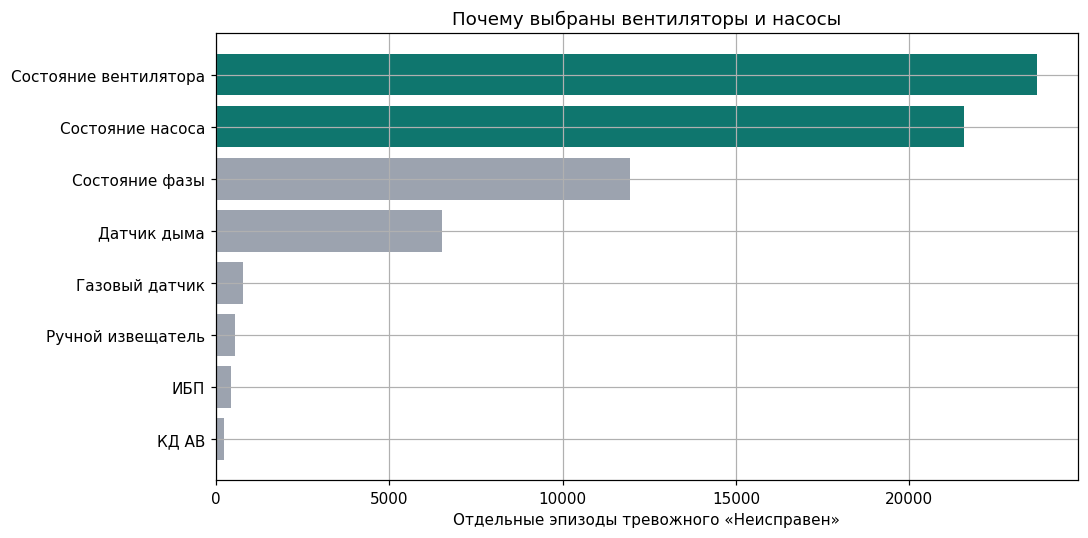

model,episodes,channels,objects,median_gap_days,repeated_within_30d
str,i64,i64,i64,f64,f64
"""ventilation""",23681,235,12,10.350758,0.791052
"""pumps""",21570,180,18,9.59151,0.808509


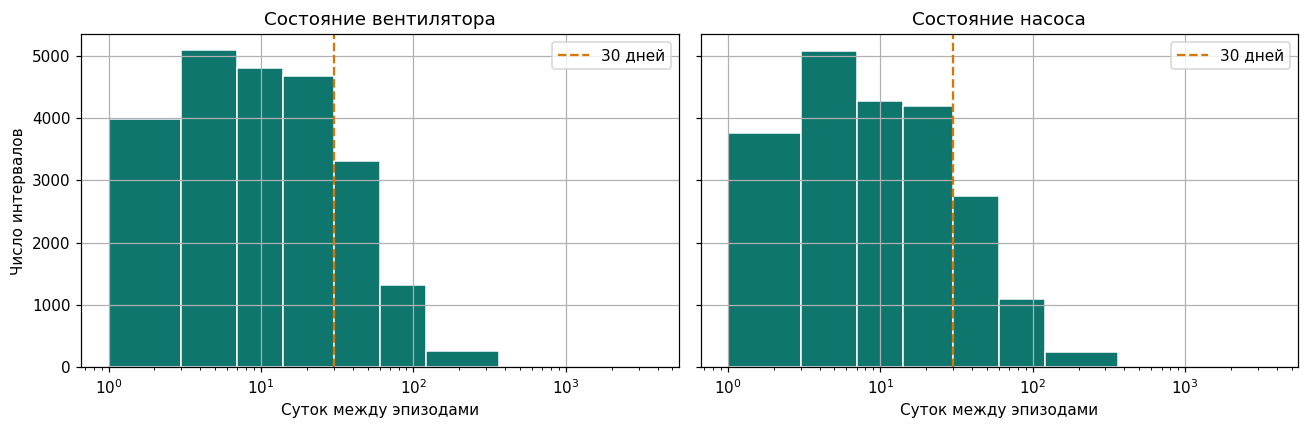

In [3]:
by_type = all_episodes.group_by('type').agg(
    pl.len().alias('episodes'),
    pl.col('channel').n_unique().alias('channels'),
    pl.col('object_id').n_unique().alias('objects'),
).sort('episodes', descending=True)
display(by_type.head(10))

top = by_type.head(8).reverse()
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#0f766e' if name in (FAN, PUMP) else '#9ca3af' for name in top['type']]
ax.barh(top['type'], top['episodes'], color=colors)
ax.set(xlabel='Отдельные эпизоды тревожного «Неисправен»', title='Почему выбраны вентиляторы и насосы')
fig.tight_layout()
fig.savefig(FIGURES / '01_types.png', bbox_inches='tight')
plt.show()

repeat_rows = []
for model, sensor_type in SENSORS.items():
    part = episodes.filter(pl.col('type') == sensor_type)
    gaps = part['gap_days'].drop_nulls().to_numpy()
    repeat_rows.append({
        'model': model, 'episodes': part.height, 'channels': part['channel'].n_unique(),
        'objects': part['object_id'].n_unique(), 'median_gap_days': float(np.median(gaps)),
        'repeated_within_30d': float(np.mean(gaps <= 30)),
    })
repeats = pl.DataFrame(repeat_rows)
display(repeats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (model, sensor_type) in zip(axes, SENSORS.items()):
    gaps = episodes.filter(pl.col('type') == sensor_type)['gap_days'].drop_nulls().to_numpy()
    ax.hist(gaps, bins=[1, 3, 7, 14, 30, 60, 120, 365, 3650], color='#0f766e', edgecolor='white')
    ax.axvline(30, color='#d97706', linestyle='--', label='30 дней')
    ax.set(xscale='log', xlabel='Суток между эпизодами', title=sensor_type)
    ax.legend()
axes[0].set_ylabel('Число интервалов')
fig.tight_layout()
fig.savefig(FIGURES / '02_recurrence.png', bbox_inches='tight')
plt.show()


**Граница применимости.** Для расчёта нужен хотя бы один прошлый целевой эпизод того же канала. Если истории нет, сервис возвращает `insufficient_history`. Другие типы датчиков не получают оценку от этих двух моделей.


## Единица прогноза и целевая переменная

Одна строка обучения — **канал × день в 00:00**. Строку берём, если до этого дня уже была целевая тревога, за последние сутки новой тревоги не было, а объект отправлял любые показания в последние 7 дней. `y=1`, если новый эпизод начнётся в интервале **[дата + 1 сутки; дата + 31 сутки)**; иначе `y=0`. Соседние дни могут ссылаться на один будущий эпизод, поэтому это не число независимых поломок.


## 13 признаков: только прошлое этого канала

| Признак | Что означает |
|---|---|
| `age_days` | Сутки с начала последнего эпизода. |
| `raw_age_days` | Сутки с последнего тревожного сообщения, даже внутри эпизода. |
| `last_gap_days` | Пауза между двумя последними эпизодами. |
| `mean_last_gaps_days` | Средняя пауза не более чем по трём завершённым интервалам. |
| `age_gap_ratio` | Текущая давность относительно обычной паузы. |
| `episodes_7d`, `episodes_30d`, `episodes_90d`, `episodes_365d` | Число новых эпизодов в четырёх прошлых окнах. Это **четыре отдельных числа**. |
| `weekday_sin`, `weekday_cos` | Две координаты дня недели; соседние воскресенье и понедельник остаются близкими. |
| `month_sin`, `month_cos` | Две координаты месяца по тому же принципу. |

Итого **5 + 4 + 2 + 2 = 13** чисел. Значение 3650 суток обозначает неизвестный интервал до появления достаточной истории. ID объекта, тег и состояния соседних каналов в эту модель не входят.


In [4]:
FEATURES = [
    'age_days', 'raw_age_days', 'last_gap_days', 'mean_last_gaps_days', 'age_gap_ratio',
    'episodes_7d', 'episodes_30d', 'episodes_90d', 'episodes_365d',
    'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos',
]

def make_features(times, raw, starts):
    timestamps = times.cast(pl.Int64).to_numpy()
    previous = np.searchsorted(starts, timestamps) - 1
    previous_raw = np.searchsorted(raw, timestamps) - 1
    age = np.full(len(times), 3650.0)
    raw_age = np.full(len(times), 3650.0)
    known = previous >= 0
    known_raw = previous_raw >= 0
    age[known] = (timestamps[known] - starts[previous[known]]) / DAY_US
    raw_age[known_raw] = (timestamps[known_raw] - raw[previous_raw[known_raw]]) / DAY_US
    last_gap = np.full(len(times), 3650.0)
    mean_gap = np.full(len(times), 3650.0)
    if len(starts) >= 2:
        gaps = np.r_[0, np.diff(starts) / DAY_US]
        have_gap = previous >= 1
        last_gap[have_gap] = gaps[previous[have_gap]]
        prefix = np.r_[0, np.cumsum(gaps)]
        right = previous[have_gap] + 1
        left = np.maximum(right - 3, 1)
        mean_gap[have_gap] = (prefix[right] - prefix[left]) / (right - left)
    values = {
        'age_days': np.minimum(age, 3650), 'raw_age_days': np.minimum(raw_age, 3650),
        'last_gap_days': last_gap, 'mean_last_gaps_days': mean_gap,
        'age_gap_ratio': age / np.maximum(mean_gap, 1),
    }
    for days in (7, 30, 90, 365):
        values[f'episodes_{days}d'] = (
            np.searchsorted(starts, timestamps) - np.searchsorted(starts, timestamps - days * DAY_US)
        )
    weekday = times.dt.weekday().to_numpy() - 1
    month = times.dt.month().to_numpy() - 1
    values['weekday_sin'] = np.sin(2 * np.pi * weekday / 7)
    values['weekday_cos'] = np.cos(2 * np.pi * weekday / 7)
    values['month_sin'] = np.sin(2 * np.pi * month / 12)
    values['month_cos'] = np.cos(2 * np.pi * month / 12)
    return pl.DataFrame(values).cast(pl.Float32)

fault_index = {
    key[0]: part['ts'].cast(pl.Int64).to_numpy()
    for key, part in faults.partition_by('channel', as_dict=True).items()
}
activity_index = {
    key[0]: part['day'].cast(pl.Int64).to_numpy()
    for key, part in object_days.partition_by('object_id', as_dict=True).items()
}
times = pl.datetime_range(START, DATA_END - timedelta(days=1), interval='1d', eager=True).alias('time')
timestamps = times.cast(pl.Int64).to_numpy()
datasets = {}
for model, sensor_type in SENSORS.items():
    own_cache = CACHE / f'{model}_dataset.parquet'
    if own_cache.exists():
        datasets[model] = pl.read_parquet(own_cache)
        continue
    parts = []
    for channel, object_id in focus.filter(pl.col('type') == sensor_type).select('channel', 'object_id').iter_rows():
        raw = fault_index.get(channel, np.array([], dtype=np.int64))
        if len(raw) == 0:
            continue
        starts = raw[np.r_[True, np.diff(raw) > DAY_US]]
        observed = activity_index.get(object_id, np.array([], dtype=np.int64))
        past_fault = np.searchsorted(raw, timestamps) > 0
        quiet = np.searchsorted(raw, timestamps) == np.searchsorted(raw, timestamps - DAY_US)
        active = np.searchsorted(observed, timestamps) > np.searchsorted(observed, timestamps - 7 * DAY_US)
        enough_archive = timestamps >= timestamps[0] + 30 * DAY_US
        eligible = past_fault & quiet & active & enough_archive
        future_start = np.searchsorted(starts, timestamps + DAY_US)
        future_end = np.searchsorted(starts, timestamps + 31 * DAY_US)
        y = (future_end > future_start).astype(np.int8)
        part = make_features(times, raw, starts).with_columns(
            pl.lit(channel).alias('channel'), pl.lit(object_id).alias('object_id'),
            times, pl.Series('y', y),
        ).filter(pl.Series(eligible))
        parts.append(part)
    datasets[model] = pl.concat(parts)
    datasets[model].write_parquet(own_cache)

for model, data in datasets.items():
    print(model, 'строк:', data.height, 'каналов:', data['channel'].n_unique(), 'объектов:', data['object_id'].n_unique())
display(datasets['ventilation'].select(FEATURES + ['channel', 'object_id', 'time', 'y']).head(5))


ventilation строк: 447134 каналов: 235 объектов: 12
pumps строк: 385209 каналов: 180 объектов: 18


age_days,raw_age_days,last_gap_days,mean_last_gaps_days,age_gap_ratio,episodes_7d,episodes_30d,episodes_90d,episodes_365d,weekday_sin,weekday_cos,month_sin,month_cos,channel,object_id,time,y
f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,i32,datetime[μs],i8
14.615533,14.615533,3650.0,3650.0,0.004004,0.0,1.0,1.0,1.0,0.433884,-0.900969,0.0,1.0,103904,3360,2019-01-31 00:00:00,0
15.615533,15.615533,3650.0,3650.0,0.004278,0.0,1.0,1.0,1.0,-0.433884,-0.900969,0.5,0.866025,103904,3360,2019-02-01 00:00:00,0
16.615532,16.615532,3650.0,3650.0,0.004552,0.0,1.0,1.0,1.0,-0.974928,-0.222521,0.5,0.866025,103904,3360,2019-02-02 00:00:00,0
17.615532,17.615532,3650.0,3650.0,0.004826,0.0,1.0,1.0,1.0,-0.781832,0.62349,0.5,0.866025,103904,3360,2019-02-03 00:00:00,0
18.615532,18.615532,3650.0,3650.0,0.0051,0.0,1.0,1.0,1.0,0.0,1.0,0.5,0.866025,103904,3360,2019-02-04 00:00:00,0


## Выбор горизонта

Сравниваем 3, 7, 14, 21, 30 и 60 суток **на одних и тех же допустимых днях**. Слева: AP модели и частота положительных ответов; справа: лучший Precision при Recall не ниже 0,5 на валидации. Длинный горизонт повышает и AP, и базовую частоту события: поэтому один высокий AP не делает его полезнее.


Сравнение горизонтов завершено: ventilation


Сравнение горизонтов завершено: pumps


model,days,validation_share,validation_ap,best_precision_recall_05,test_share,test_ap
str,i64,f64,f64,f64,f64,f64
"""ventilation""",3,0.147,0.298,0.265,0.173,0.288
"""ventilation""",7,0.287,0.472,0.424,0.337,0.515
"""ventilation""",14,0.45,0.625,0.577,0.531,0.724
"""ventilation""",21,0.566,0.707,0.681,0.66,0.819
"""ventilation""",30,0.669,0.787,0.777,0.768,0.878
…,…,…,…,…,…,…
"""pumps""",7,0.299,0.49,0.452,0.358,0.52
"""pumps""",14,0.456,0.648,0.624,0.55,0.703
"""pumps""",21,0.558,0.735,0.731,0.679,0.804


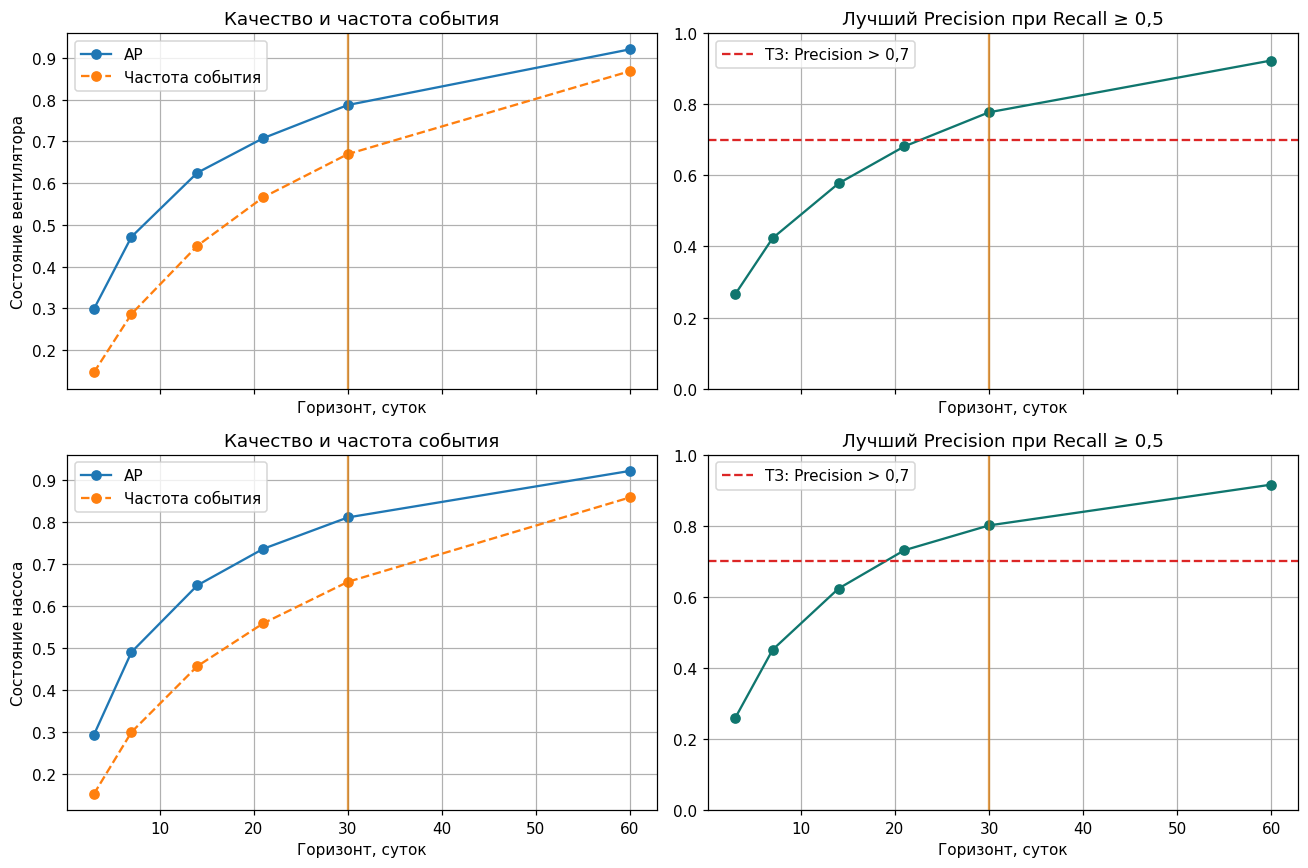

In [5]:
HORIZONS = (3, 7, 14, 21, 30, 60)

def new_estimator():
    return make_pipeline(
        StandardScaler(), LogisticRegression(C=1, max_iter=500)
    )

def add_horizon_targets(data):
    parts = []
    start_index = {
        key[0]: part['start'].cast(pl.Int64).to_numpy()
        for key, part in episodes.partition_by('channel', as_dict=True).items()
    }
    for key, part in data.partition_by('channel', as_dict=True).items():
        stamp = part['time'].cast(pl.Int64).to_numpy()
        starts = start_index[key[0]]
        left = np.searchsorted(starts, stamp + DAY_US)
        columns = [
            pl.Series(f'y_{days}d', np.searchsorted(starts, stamp + (days + 1) * DAY_US) > left)
            for days in HORIZONS
        ]
        parts.append(part.with_columns(*columns))
    result = pl.concat(parts)
    assert (result['y_30d'].cast(pl.Int8) == result['y']).all()
    return result

horizon_rows = []
for model, data in datasets.items():
    common = add_horizon_targets(data.filter(pl.col('time') < datetime(2026, 5, 1)))
    train = common.filter(pl.col('time') < datetime(2025, 5, 1))
    valid = common.filter((pl.col('time') >= VALID_START) & (pl.col('time') < datetime(2025, 11, 1)))
    late = common.filter((pl.col('time') >= TEST_START) & (pl.col('time') < datetime(2026, 5, 1)))
    for days in HORIZONS:
        label = f'y_{days}d'
        estimator = new_estimator()
        with threadpool_limits(limits=1):
            estimator.fit(train.select(FEATURES).to_numpy(), train[label].to_numpy())
            valid_score = estimator.predict_proba(valid.select(FEATURES).to_numpy())[:, 1]
            late_score = estimator.predict_proba(late.select(FEATURES).to_numpy())[:, 1]
        y_valid = valid[label].to_numpy().astype(bool)
        y_late = late[label].to_numpy().astype(bool)
        precision, recall, _ = precision_recall_curve(y_valid, valid_score)
        best_p = float(np.max(precision[recall >= 0.5]))
        horizon_rows.append({
            'model': model, 'days': days, 'validation_share': float(y_valid.mean()),
            'validation_ap': float(average_precision_score(y_valid, valid_score)),
            'best_precision_recall_05': best_p, 'test_share': float(y_late.mean()),
            'test_ap': float(average_precision_score(y_late, late_score)),
        })
    print('Сравнение горизонтов завершено:', model)
horizons = pl.DataFrame(horizon_rows)
horizons.write_csv(OUT / 'horizon_comparison.csv')
display(horizons.with_columns(pl.col(pl.Float64).round(3)))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, (model, sensor_type) in enumerate(SENSORS.items()):
    part = horizons.filter(pl.col('model') == model)
    axes[row, 0].plot(part['days'], part['validation_ap'], marker='o', label='AP')
    axes[row, 0].plot(part['days'], part['validation_share'], marker='o', linestyle='--', label='Частота события')
    axes[row, 0].set(ylabel=sensor_type, title='Качество и частота события')
    axes[row, 0].legend()
    axes[row, 1].plot(part['days'], part['best_precision_recall_05'], marker='o', color='#0f766e')
    axes[row, 1].axhline(0.7, color='#dc2626', linestyle='--', label='ТЗ: Precision > 0,7')
    axes[row, 1].set(title='Лучший Precision при Recall ≥ 0,5', ylim=(0, 1))
    axes[row, 1].legend()
    for ax in axes[row]:
        ax.axvline(30, color='#d97706', alpha=0.7)
        ax.set_xlabel('Горизонт, суток')
fig.tight_layout()
fig.savefig(FIGURES / '03_horizon_choice.png', bbox_inches='tight')
plt.show()


**Вывод.** На 14 сутках обе модели не достигают Precision 0,7 при нужной полноте; на 21 сутках — вентиляторы. **30 суток — первый общий срок**, на котором обе категории проходят границы ТЗ. При 60 сутках событие есть уже примерно в 86–87% допустимых дней, а предупреждение становится менее конкретным.


## Обучение и временная проверка

Две независимые модели — `StandardScaler` + логистическая регрессия. Обучение: 2019 — май 2025. Порог выбираем на июле–ноябре 2025; отдельно проверяем январь–май 2026. Между периодами оставлены паузы, чтобы 30-дневные ответы не пересекались. Случайное перемешивание дало бы соседние дни одного канала одновременно в обучении и проверке.


In [6]:
def split_30d(data):
    train = data.filter(pl.col('time') < TRAIN_END)
    valid = data.filter((pl.col('time') >= VALID_START) & (pl.col('time') < VALID_END))
    test = data.filter((pl.col('time') >= TEST_START) & (pl.col('time') < TEST_END))
    return {'train': train, 'validation': valid, 'test': test}

def quality(labels, scores, threshold):
    y = np.asarray(labels).astype(bool)
    warning = np.asarray(scores) >= threshold
    tp = int(np.sum(y & warning))
    fp = int(np.sum(~y & warning))
    fn = int(np.sum(y & ~warning))
    return {
        'rows': len(y), 'positive_share': float(np.mean(y)),
        'average_precision': float(average_precision_score(y, scores)),
        'brier': float(brier_score_loss(y, scores)),
        'warning_share': float(np.mean(warning)),
        'precision': tp / max(tp + fp, 1), 'recall': tp / max(tp + fn, 1),
        'tp': tp, 'fp': fp, 'fn': fn,
    }

splits = {model: split_30d(data) for model, data in datasets.items()}
split_rows = [
    {'model': model, 'period': period, 'rows': part.height,
     'channels': part['channel'].n_unique(), 'objects': part['object_id'].n_unique(),
     'positive_share': float(part['y'].mean())}
    for model, three in splits.items() for period, part in three.items()
]
display(pl.DataFrame(split_rows).with_columns(pl.col(pl.Float64).round(3)))

evaluation_models = {}
scores_by_model = {}
metric_rows = []
for model, three in splits.items():
    estimator = new_estimator()
    start_fit = perf_counter()
    with threadpool_limits(limits=1):
        estimator.fit(three['train'].select(FEATURES).to_numpy(), three['train']['y'].to_numpy())
        scores = {
            period: estimator.predict_proba(part.select(FEATURES).to_numpy())[:, 1]
            for period, part in three.items()
        }
    evaluation_models[model] = estimator
    scores_by_model[model] = scores
    print(model, 'обучение:', round(perf_counter() - start_fit, 2), 'с')
    for period, part in three.items():
        for threshold in (0.5, THRESHOLD):
            metric_rows.append({
                'model': model, 'period': period, 'threshold': threshold,
                **quality(part['y'].to_numpy(), scores[period], threshold),
            })
        if period != 'train':
            part.select('channel', 'object_id', 'time', 'y').with_columns(
                pl.Series('risk_score', scores[period])
            ).write_parquet(OUT / f'{model}_{period}_predictions.parquet')
    joblib.dump({
        'estimator': estimator, 'features': FEATURES, 'threshold': THRESHOLD,
        'trained_before': TRAIN_END.isoformat(), 'purpose': 'temporal evaluation only',
    }, MODELS / f'{model}_evaluation.joblib')

metrics = pl.DataFrame(metric_rows)
metrics.write_csv(OUT / 'temporal_quality.csv')
display(metrics.filter(pl.col('period') != 'train').select(
    'model', 'period', 'threshold', 'positive_share', 'average_precision',
    'warning_share', 'precision', 'recall', 'tp', 'fp', 'fn',
).with_columns(pl.col(pl.Float64).round(3)))


model,period,rows,channels,objects,positive_share
str,str,i64,i64,i64,f64
"""ventilation""","""train""",364881,211,11,0.675
"""ventilation""","""validation""",30387,211,11,0.682
"""ventilation""","""test""",32637,235,12,0.78
"""pumps""","""train""",321207,169,17,0.685
"""pumps""","""validation""",24228,169,17,0.657
"""pumps""","""test""",24861,180,18,0.795


ventilation обучение: 0.22 с


pumps обучение: 0.2 с


model,period,threshold,positive_share,average_precision,warning_share,precision,recall,tp,fp,fn
str,str,f64,f64,f64,f64,f64,f64,i64,i64,i64
"""ventilation""","""validation""",0.5,0.682,0.785,0.972,0.688,0.98,20309,9218,424
"""ventilation""","""validation""",0.7,0.682,0.785,0.504,0.762,0.563,11673,3646,9060
"""ventilation""","""test""",0.5,0.78,0.886,0.977,0.787,0.985,25099,6798,373
"""ventilation""","""test""",0.7,0.78,0.886,0.54,0.854,0.591,15051,2577,10421
"""pumps""","""validation""",0.5,0.657,0.8,0.937,0.666,0.951,15128,7578,784
"""pumps""","""validation""",0.7,0.657,0.8,0.521,0.754,0.598,9518,3108,6394
"""pumps""","""test""",0.5,0.795,0.891,0.968,0.801,0.975,19272,4784,486
"""pumps""","""test""",0.7,0.795,0.891,0.614,0.85,0.657,12972,2288,6786


### Выбор алгоритма

Сравниваем логистическую регрессию с бустингом на одинаковых временных срезах. Итог — две логистические модели: они проще, быстро обучаются и на поздней проверке для насосов дают чуть лучшее ранжирование и меньше предупреждений при пороге 0,70.


In [7]:
family_rows = []
for model, three in splits.items():
    alternatives = {
        'Логистическая регрессия': evaluation_models[model],
        'Градиентный бустинг': HistGradientBoostingClassifier(
            max_iter=120, max_leaf_nodes=15, min_samples_leaf=100,
            learning_rate=0.08, l2_regularization=10.0,
            early_stopping=False, random_state=42,
        ),
    }
    with threadpool_limits(limits=1):
        alternatives['Градиентный бустинг'].fit(
            three['train'].select(FEATURES).to_numpy(), three['train']['y'].to_numpy()
        )
        for name, estimator in alternatives.items():
            for period in ('validation', 'test'):
                part = three[period]
                scores = estimator.predict_proba(part.select(FEATURES).to_numpy())[:, 1]
                result = quality(part['y'].to_numpy(), scores, THRESHOLD)
                family_rows.append({
                    'model': model, 'algorithm': name, 'period': period,
                    'ap': result['average_precision'], 'warning_share': result['warning_share'],
                    'precision': result['precision'], 'recall': result['recall'],
                })
families = pl.DataFrame(family_rows)
families.write_csv(OUT / 'algorithm_comparison.csv')
display(families.with_columns(pl.col(pl.Float64).round(3)))


model,algorithm,period,ap,warning_share,precision,recall
str,str,str,f64,f64,f64,f64
"""ventilation""","""Логистическая регрессия""","""validation""",0.785,0.504,0.762,0.563
"""ventilation""","""Логистическая регрессия""","""test""",0.886,0.54,0.854,0.591
"""ventilation""","""Градиентный бустинг""","""validation""",0.797,0.559,0.768,0.629
"""ventilation""","""Градиентный бустинг""","""test""",0.866,0.6,0.818,0.629
"""pumps""","""Логистическая регрессия""","""validation""",0.8,0.521,0.754,0.598
"""pumps""","""Логистическая регрессия""","""test""",0.891,0.614,0.85,0.657
"""pumps""","""Градиентный бустинг""","""validation""",0.787,0.63,0.728,0.699
"""pumps""","""Градиентный бустинг""","""test""",0.881,0.657,0.83,0.686


## Качество и порог предупреждения

Precision — доля верных предупреждений; Recall — доля найденных положительных дней. PR-кривая показывает все возможные пороги, точка на ней — рабочий порог **0,70**. Следующий график показывает, как порог меняет Precision, Recall и долю дней с предупреждением. Сравнение порогов проводим на валидации, после чего показываем результат на более позднем периоде.


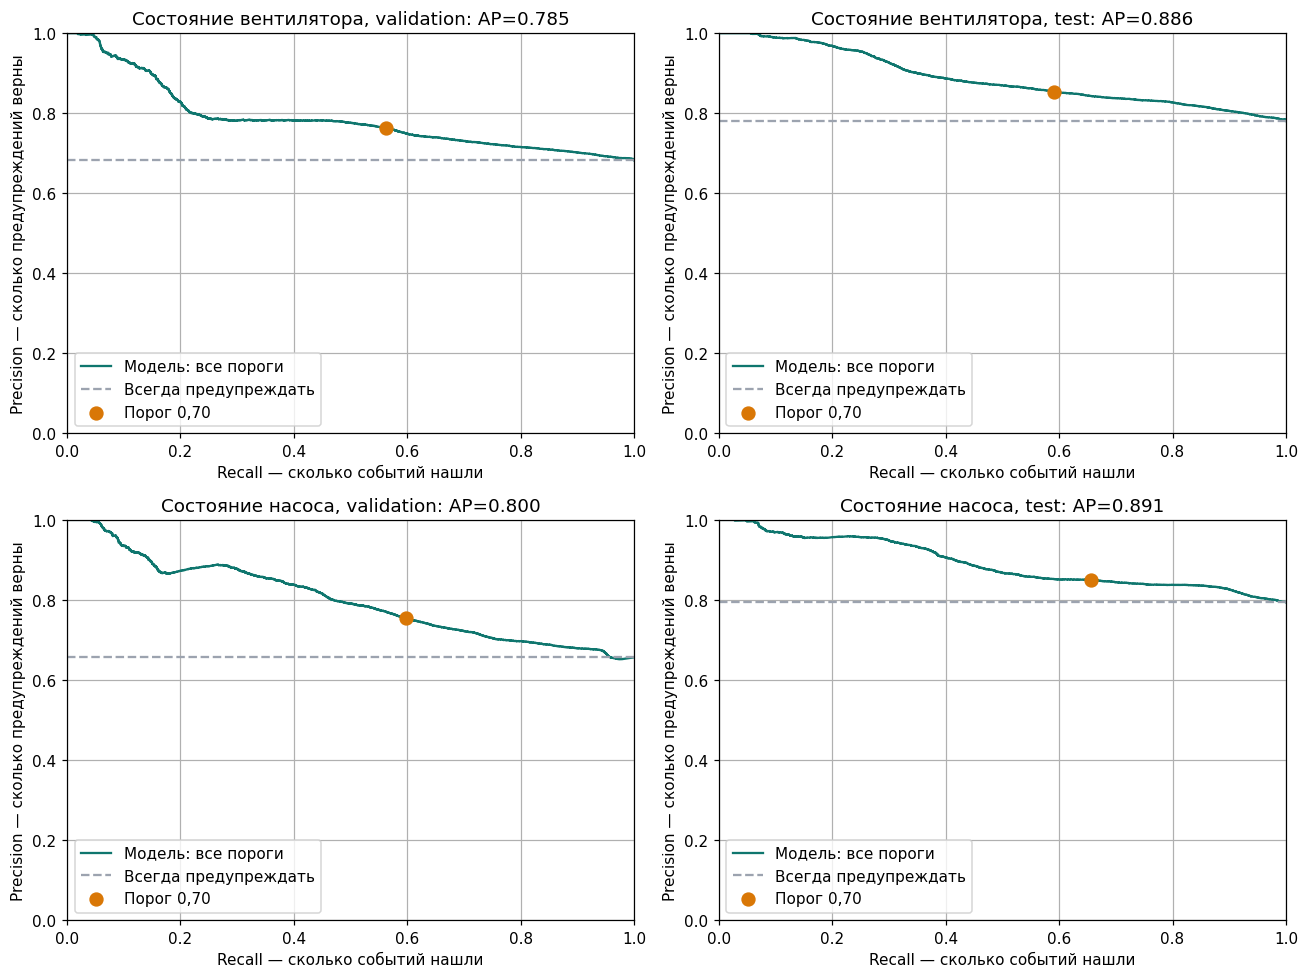

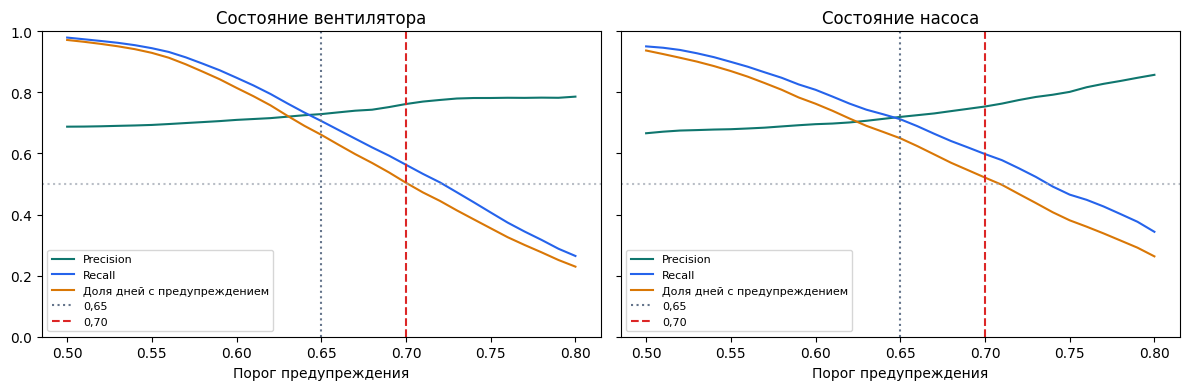

In [8]:
threshold_rows = []
for model, three in splits.items():
    labels = three['validation']['y'].to_numpy()
    scores = scores_by_model[model]['validation']
    for threshold in np.arange(0.50, 0.801, 0.01):
        threshold_rows.append({
            'model': model, 'threshold': round(float(threshold), 2),
            **quality(labels, scores, threshold),
        })
thresholds = pl.DataFrame(threshold_rows)
thresholds.write_csv(OUT / 'validation_thresholds.csv')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, (model, sensor_type) in enumerate(SENSORS.items()):
    for col, period in enumerate(('validation', 'test')):
        part = splits[model][period]
        labels = part['y'].to_numpy()
        scores = scores_by_model[model][period]
        precision, recall, _ = precision_recall_curve(labels, scores)
        point = quality(labels, scores, THRESHOLD)
        ax = axes[row, col]
        ax.plot(recall, precision, color='#0f766e', label='Модель: все пороги')
        ax.axhline(float(np.mean(labels)), color='#9ca3af', linestyle='--', label='Всегда предупреждать')
        ax.scatter(point['recall'], point['precision'], color='#d97706', s=70, label='Порог 0,70', zorder=3)
        ax.set(xlabel='Recall — сколько событий нашли', ylabel='Precision — сколько предупреждений верны',
               title=f'{sensor_type}, {period}: AP={point["average_precision"]:.3f}', xlim=(0, 1), ylim=(0, 1))
        ax.legend(loc='lower left')
fig.tight_layout()
fig.savefig(FIGURES / '04_precision_recall.png', bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (model, sensor_type) in zip(axes, SENSORS.items()):
    part = thresholds.filter(pl.col('model') == model)
    ax.plot(part['threshold'], part['precision'], label='Precision', color='#0f766e')
    ax.plot(part['threshold'], part['recall'], label='Recall', color='#2563eb')
    ax.plot(part['threshold'], part['warning_share'], label='Доля дней с предупреждением', color='#d97706')
    ax.axvline(0.65, color='#64748b', linestyle=':', label='0,65')
    ax.axvline(THRESHOLD, color='#dc2626', linestyle='--', label='0,70')
    ax.axhline(0.5, color='#9ca3af', linestyle=':', alpha=0.7)
    ax.set(xlabel='Порог предупреждения', title=sensor_type, ylim=(0, 1))
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / '05_threshold_tradeoff.png', bbox_inches='tight')
plt.show()


## Проверка устойчивости при добавлении истории

Здесь модель переобучается с всё большим объёмом **прошлых** лет, а валидация остаётся одной и той же. По оси Y — AP сверх частоты события. Линии обучения и валидации сопоставимы; добавление истории не вызывает резкого падения качества. Это проверка обобщения, а не график итераций оптимизатора — он показан следующим.


model,through,period,train_rows,evaluated_rows,ap,prevalence,ap_above_prevalence
str,str,str,i64,i64,f64,f64,f64
"""ventilation""","""2022-01-01""","""train""",122658,122658,0.755,0.649,0.105
"""ventilation""","""2022-01-01""","""validation""",122658,30387,0.775,0.682,0.092
"""ventilation""","""2024-01-01""","""train""",262066,262066,0.747,0.656,0.091
"""ventilation""","""2024-01-01""","""validation""",262066,30387,0.785,0.682,0.103
"""ventilation""","""2025-06-01""","""train""",364881,364881,0.78,0.675,0.104
…,…,…,…,…,…,…,…
"""pumps""","""2022-01-01""","""validation""",126207,24228,0.79,0.657,0.134
"""pumps""","""2024-01-01""","""train""",239408,239408,0.771,0.659,0.113
"""pumps""","""2024-01-01""","""validation""",239408,24228,0.797,0.657,0.141


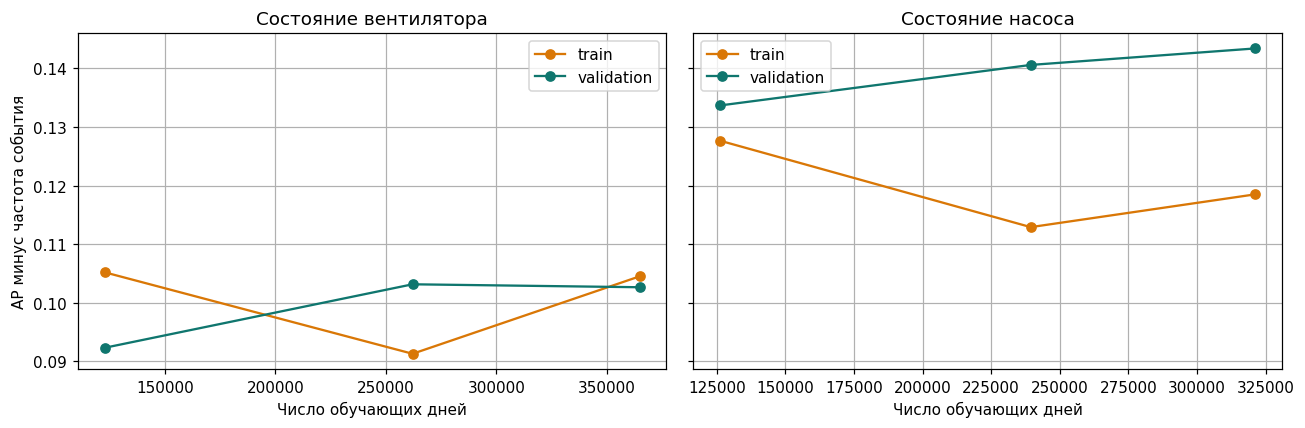

In [9]:
learning_rows = []
cutoffs = [datetime(2022, 1, 1), datetime(2024, 1, 1), TRAIN_END]
for model, three in splits.items():
    for cutoff in cutoffs:
        smaller = three['train'].filter(pl.col('time') < cutoff)
        estimator = new_estimator()
        with threadpool_limits(limits=1):
            estimator.fit(smaller.select(FEATURES).to_numpy(), smaller['y'].to_numpy())
            train_score = estimator.predict_proba(smaller.select(FEATURES).to_numpy())[:, 1]
            valid_score = estimator.predict_proba(three['validation'].select(FEATURES).to_numpy())[:, 1]
        for period, part, score in (('train', smaller, train_score), ('validation', three['validation'], valid_score)):
            prevalence = float(part['y'].mean())
            learning_rows.append({
                'model': model, 'through': cutoff.date().isoformat(), 'period': period,
                'train_rows': smaller.height, 'evaluated_rows': part.height,
                'ap': float(average_precision_score(part['y'].to_numpy(), score)),
                'prevalence': prevalence,
            })
learning = pl.DataFrame(learning_rows).with_columns(
    (pl.col('ap') - pl.col('prevalence')).alias('ap_above_prevalence')
)
learning.write_csv(OUT / 'learning_curve.csv')
display(learning.with_columns(pl.col(pl.Float64).round(3)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (model, sensor_type) in zip(axes, SENSORS.items()):
    for period, color in (('train', '#d97706'), ('validation', '#0f766e')):
        part = learning.filter((pl.col('model') == model) & (pl.col('period') == period))
        ax.plot(part['train_rows'], part['ap_above_prevalence'], marker='o', color=color, label=period)
    ax.set(xlabel='Число обучающих дней', title=sensor_type)
    ax.legend()
axes[0].set_ylabel('AP минус частота события')
fig.tight_layout()
fig.savefig(FIGURES / '06_learning_curve.png', bbox_inches='tight')
plt.show()


**Вывод.** Разрыв между обучением и валидацией невелик, явного переобучения по этому сравнению нет. Модель ранжирует лучше простого ориентира, но выигрыш над частотой события умеренный; поэтому отдельно показываем рабочие Precision и Recall.


## Сходимость по итерациям

В отличие от предыдущего графика здесь по оси X — **шаги оптимизатора L-BFGS**, а по оси Y — ошибка Log loss на обучении и валидации. Ошибка быстро падает и выходит на плато; валидационная линия остаётся близкой к обучающей. Это согласуется с отсутствием явного переобучения в этой проверке. Диагностический запуск продолжен до сходимости; сохранённые финальные модели sklearn остановились за 19 и 22 итерации соответственно.


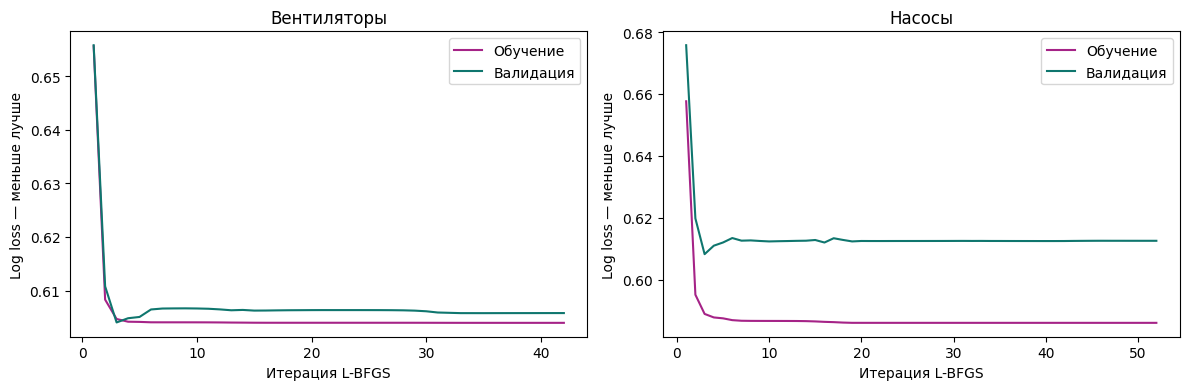

In [ ]:
from scipy.optimize import minimize
from scipy.special import expit
from sklearn.metrics import log_loss

def optimizer_trace(model):
    train = splits[model]['train']
    valid = splits[model]['validation']
    scaler = evaluation_models[model].named_steps['standardscaler']
    x_train = scaler.transform(train.select(FEATURES).to_numpy()).astype(np.float64)
    x_valid = scaler.transform(valid.select(FEATURES).to_numpy()).astype(np.float64)
    y_train = train['y'].to_numpy().astype(np.float64)
    y_valid = valid['y'].to_numpy().astype(np.float64)
    n = len(y_train)
    history = []

    # Повторяем задачу оптимизации логистической регрессии и записываем ошибку после каждого шага.
    def objective(weights):
        linear = x_train @ weights[:-1] + weights[-1]
        residual = expit(linear) - y_train
        loss = np.mean(np.logaddexp(0, linear) - y_train * linear)
        loss += np.dot(weights[:-1], weights[:-1]) / (2 * n)
        gradient = np.r_[x_train.T @ residual / n + weights[:-1] / n, residual.mean()]
        return loss, gradient

    def record(weights):
        train_score = expit(x_train @ weights[:-1] + weights[-1])
        valid_score = expit(x_valid @ weights[:-1] + weights[-1])
        history.append({
            'model': model, 'iteration': len(history) + 1,
            'train_loss': log_loss(y_train, train_score),
            'validation_loss': log_loss(y_valid, valid_score),
        })

    with threadpool_limits(limits=1):
        result = minimize(
            objective, np.zeros(x_train.shape[1] + 1), jac=True,
            method='L-BFGS-B', callback=record,
            options={'maxiter': 120, 'ftol': 1e-10, 'gtol': 1e-8},
        )
    assert result.success, result.message
    return pl.DataFrame(history)

traces = pl.concat([optimizer_trace(model) for model in SENSORS])
traces.write_csv(OUT / 'training_iterations.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (model, sensor_type) in zip(axes, SENSORS.items()):
    part = traces.filter(pl.col('model') == model)
    ax.plot(part['iteration'], part['train_loss'], label='Обучение', color='#a52387')
    ax.plot(part['iteration'], part['validation_loss'], label='Валидация', color='#0f766e')
    ax.set(title=sensor_type, xlabel='Итерация L-BFGS', ylabel='Log loss — меньше лучше')
    ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / '08_training_iterations.png', bbox_inches='tight')
plt.show()


## ROC/AUC на будущих датах

ROC показывает, как растёт доля найденных событий при увеличении доли ложных тревог. Пунктирная диагональ соответствует случайному ранжированию (AUC 0,5). Наши кривые выше неё: AUC **0,620–0,658** на валидации и **0,672–0,675** на поздней проверке. Это умеренная способность разделять дни по риску; рабочее качество при пороге 0,70 показано отдельно ниже.


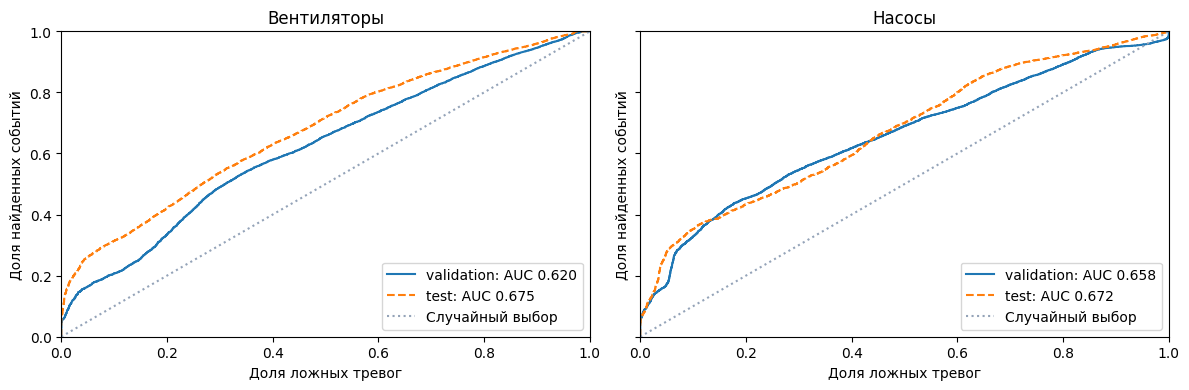

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

auc_rows = []
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
for ax, (model, sensor_type) in zip(axes, SENSORS.items()):
    for period, style in [('validation', '-'), ('test', '--')]:
        labels = splits[model][period]['y'].to_numpy()
        scores = scores_by_model[model][period]
        fpr, tpr, _ = roc_curve(labels, scores)
        auc = roc_auc_score(labels, scores)
        auc_rows.append({'model': model, 'period': period, 'roc_auc': auc})
        ax.plot(fpr, tpr, style, label=f'{period}: AUC {auc:.3f}')
    ax.plot([0, 1], [0, 1], ':', color='#94a3b8', label='Случайный выбор')
    ax.set(title=sensor_type, xlabel='Доля ложных тревог', ylabel='Доля найденных событий', xlim=(0, 1), ylim=(0, 1))
    ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIGURES / '09_roc_auc.png', bbox_inches='tight')
plt.show()
roc_summary = pl.DataFrame(auc_rows)
roc_summary.write_csv(OUT / 'roc_auc.csv')
display(roc_summary.with_columns(pl.col('roc_auc').round(3)))


## Итоговые метрики двух моделей

На поздней проверке при фиксированном пороге 0,70 обе модели проходят требования ТЗ. Столбцы показывают фактические Precision и Recall; пунктир — границы 0,70 и 0,50. Для понимания рабочей нагрузки рядом в таблице есть доля дней с предупреждением.


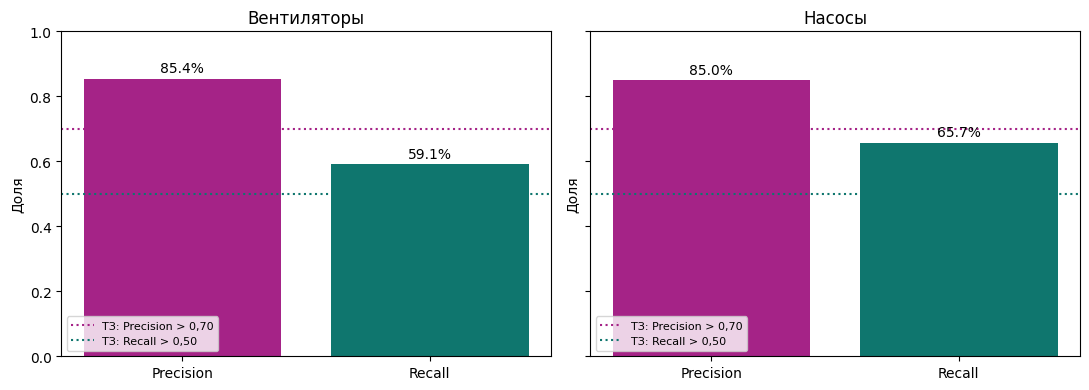

In [ ]:
late_quality = metrics.filter(
    (pl.col('period') == 'test') & (pl.col('threshold') == THRESHOLD)
).select('model', 'rows', 'positive_share', 'warning_share', 'precision', 'recall', 'tp', 'fp', 'fn')
display(late_quality.with_columns(pl.col(pl.Float64).round(3)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (model, sensor_type) in zip(axes, SENSORS.items()):
    result = late_quality.filter(pl.col('model') == model).row(0, named=True)
    values = [result['precision'], result['recall']]
    bars = ax.bar(['Precision', 'Recall'], values, color=['#a52387', '#0f766e'])
    ax.axhline(0.70, color='#a52387', linestyle=':', label='ТЗ: Precision > 0,70')
    ax.axhline(0.50, color='#0f766e', linestyle=':', label='ТЗ: Recall > 0,50')
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.1%}', ha='center')
    ax.set(title=sensor_type, ylabel='Доля', ylim=(0, 1))
    ax.legend(loc='lower left', fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / '10_final_metrics.png', bbox_inches='tight')
plt.show()


## Какие признаки помогают

Перемешиваем один признак в строках валидации и измеряем падение AP. Большое падение означает, что информация в этом признаке нужна модели. Такой способ показывает вклад в ранжирование, а не причинность поломки.


model,feature,ap_drop
str,str,f64
"""pumps""","""episodes_365d""",0.103
"""pumps""","""episodes_30d""",0.009
"""pumps""","""month_cos""",0.002
"""pumps""","""mean_last_gaps_days""",0.001
"""pumps""","""episodes_7d""",0.001
…,…,…
"""ventilation""","""age_days""",0.002
"""ventilation""","""month_sin""",0.001
"""ventilation""","""episodes_7d""",0.001


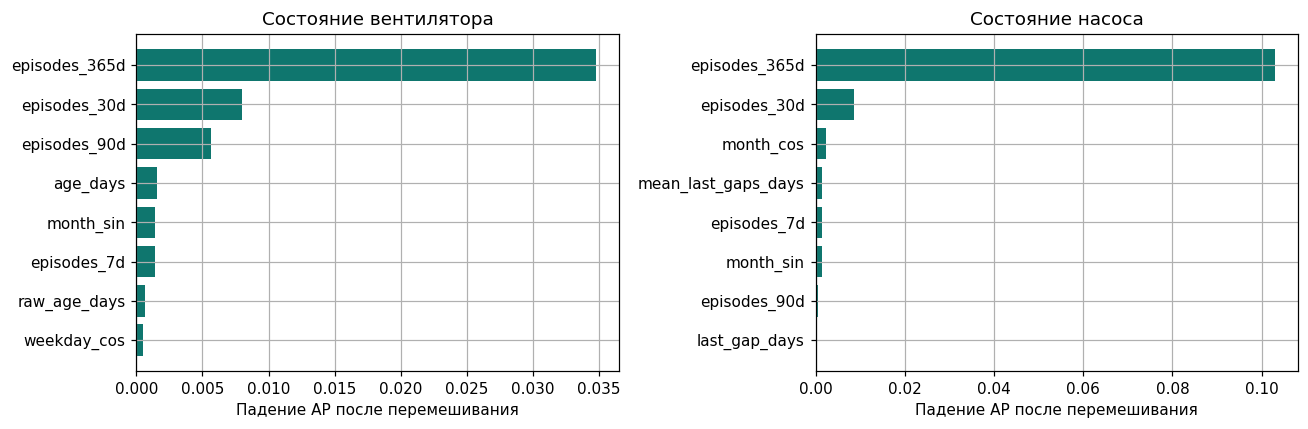

In [10]:
importance_rows = []
rng = np.random.default_rng(42)
for model, three in splits.items():
    sample = three['validation'].sample(n=min(10_000, three['validation'].height), seed=42)
    matrix = sample.select(FEATURES).to_numpy()
    labels = sample['y'].to_numpy()
    estimator = evaluation_models[model]
    reference = average_precision_score(labels, estimator.predict_proba(matrix)[:, 1])
    for column, feature in enumerate(FEATURES):
        changed = matrix.copy()
        changed[:, column] = rng.permutation(changed[:, column])
        altered = average_precision_score(labels, estimator.predict_proba(changed)[:, 1])
        importance_rows.append({'model': model, 'feature': feature, 'ap_drop': reference - altered})
importance = pl.DataFrame(importance_rows)
importance.write_csv(OUT / 'feature_importance.csv')
display(importance.sort('model', 'ap_drop', descending=[False, True]).group_by('model').head(8).with_columns(pl.col(pl.Float64).round(3)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (model, sensor_type) in zip(axes, SENSORS.items()):
    part = importance.filter(pl.col('model') == model).sort('ap_drop').tail(8)
    ax.barh(part['feature'], part['ap_drop'], color='#0f766e')
    ax.set(xlabel='Падение AP после перемешивания', title=sensor_type)
fig.tight_layout()
fig.savefig(FIGURES / '07_feature_importance.png', bbox_inches='tight')
plt.show()


**Вывод.** Число эпизодов за последние 365 дней влияет сильнее всего; давность и короткие окна дополняют годовую историю. Календарные признаки дают небольшой вклад. Это согласуется с EDA: главный сигнал — повторяемость целевой тревоги на том же канале.


## Проверка отдельных эпизодов

Одно событие может дать много положительных дневных строк. Поэтому дополнительно считаем долю **уникальных будущих эпизодов**, перед которыми был хотя бы один своевременный сигнал. Эта метрика отвечает на вопрос, сколько отдельных случаев модель помогла заметить заранее.


In [11]:
def event_coverage(model, period):
    part = splits[model][period]
    start = VALID_START if period == 'validation' else TEST_START
    end = VALID_END if period == 'validation' else TEST_END
    target_events = episodes.filter(
        (pl.col('type') == SENSORS[model])
        & (pl.col('start') >= start + timedelta(days=31))
        & (pl.col('start') < end)
    )
    warnings = part.select('channel', 'time').filter(
        pl.Series(scores_by_model[model][period] >= THRESHOLD)
    )
    by_channel = {
        key[0]: np.sort(group['time'].cast(pl.Int64).to_numpy())
        for key, group in warnings.partition_by('channel', as_dict=True).items()
    }
    detected = 0
    for channel, start_time in target_events.select('channel', pl.col('start').cast(pl.Int64)).iter_rows():
        dates = by_channel.get(channel, np.array([], dtype=np.int64))
        after = np.searchsorted(dates, start_time - 31 * DAY_US, side='right')
        before = np.searchsorted(dates, start_time - DAY_US, side='right')
        detected += int(before > after)
    return {
        'model': model, 'period': period, 'episodes': target_events.height,
        'warned_episodes': detected, 'event_recall': detected / target_events.height,
    }

coverage = pl.DataFrame([
    event_coverage(model, period)
    for model in SENSORS for period in ('validation', 'test')
])
coverage.write_csv(OUT / 'event_coverage.csv')
display(coverage.with_columns(pl.col(pl.Float64).round(3)))


model,period,episodes,warned_episodes,event_recall
str,str,i64,i64,f64
"""ventilation""","""validation""",1155,908,0.786
"""ventilation""","""test""",2033,1682,0.827
"""pumps""","""validation""",966,743,0.769
"""pumps""","""test""",1619,1418,0.876


## Почему порог 0,70

При `risk_score ≥ 0,70` сервис показывает предупреждение. На валидации порог 0,50 предупреждал почти каждый допустимый день. При 0,70 Precision/Recall составили **0,762/0,563** для вентиляторов и **0,754/0,598** для насосов; доля дней с предупреждением снизилась до 50–52%. Порог 0,65 тоже проходит ТЗ, но даёт больше предупреждений. Порог не меняет обученные веса и не означает точную вероятность отказа в каждом отдельном случае.


In [12]:
decision_table = metrics.filter(pl.col('period') != 'train').with_columns(
    (pl.col('warning_share') * 100).alias('warning_share'),
    (pl.col('precision') * 100).alias('precision'),
    (pl.col('recall') * 100).alias('recall'),
)
display(decision_table.select(
    'model', 'period', 'threshold', 'warning_share', 'precision', 'recall',
).with_columns(pl.col(pl.Float64).round(1)))


model,period,threshold,warning_share,precision,recall
str,str,f64,f64,f64,f64
"""ventilation""","""validation""",0.5,97.2,68.8,98.0
"""ventilation""","""validation""",0.7,50.4,76.2,56.3
"""ventilation""","""test""",0.5,97.7,78.7,98.5
"""ventilation""","""test""",0.7,54.0,85.4,59.1
"""pumps""","""validation""",0.5,93.7,66.6,95.1
"""pumps""","""validation""",0.7,52.1,75.4,59.8
"""pumps""","""test""",0.5,96.8,80.1,97.5
"""pumps""","""test""",0.7,61.4,85.0,65.7


## Сохранение моделей

Проверенные выше веса обучались только до июня 2025. Для передачи в MVP отдельно обучаем две модели на всех полностью размеченных днях по май 2026, затем сохраняем Joblib-пакеты с весами, 13 признаками, справочником каналов, горизонтом и порогом 0,70. Поздние метрики относятся к **проверочным**, а не к дообученным финальным весам; окончательным весам нужна новая размеченная история для внешнего теста.


In [13]:
# Пакет сохраняет поля, которые читает существующий сервис MVP.
required_fields = {
    'estimator', 'features', 'channel_codes', 'registry', 'threshold',
    'lead_hours', 'window_hours', 'quiet_hours', 'activity_days',
}

model_manifest = []
final_bundles = {}
for model, data in datasets.items():
    final_train = data.filter(pl.col('time') < datetime(2026, 6, 1))
    estimator = new_estimator()
    start_fit = perf_counter()
    with threadpool_limits(limits=1):
        estimator.fit(final_train.select(FEATURES).to_numpy(), final_train['y'].to_numpy())
    registry_rows = focus.filter(pl.col('type') == SENSORS[model]).sort('channel').to_dicts()
    channel_codes = {row['channel']: number for number, row in enumerate(registry_rows)}
    bundle = {
        'estimator': estimator, 'features': FEATURES, 'model_key': model,
        'sensor_type': SENSORS[model], 'model_version': f'{model}-30d-t070-through-2026-05',
        'threshold': THRESHOLD, 'channel_codes': channel_codes, 'registry': registry_rows,
        'lead_hours': 24, 'window_hours': 720, 'quiet_hours': 24, 'activity_days': 7,
        'timezone': 'Europe/Moscow', 'training_start': START.isoformat(),
        'training_data_end_exclusive': DATA_END.isoformat(),
        'last_fully_labeled_forecast_at': final_train['time'].max().isoformat(),
        'threshold_policy': 'fixed_0.70',
    }
    assert required_fields <= bundle.keys()
    assert len(bundle['features']) == 13
    path = MODELS / f'{model}.joblib'
    joblib.dump(bundle, path)
    (MODELS / f'{model}_metadata.json').write_text(
        json.dumps({key: value for key, value in bundle.items() if key != 'estimator'}, ensure_ascii=False, indent=2)
    )
    final_bundles[model] = bundle
    model_manifest.append({
        'model': model, 'file': str(path), 'train_rows': final_train.height,
        'train_channels': final_train['channel'].n_unique(),
        'last_training_day': str(final_train['time'].max()),
        'threshold': THRESHOLD, 'fit_seconds': round(perf_counter() - start_fit, 2),
    })
manifest = pl.DataFrame(model_manifest)
manifest.write_csv(OUT / 'final_model_manifest.csv')
display(manifest)


model,file,train_rows,train_channels,last_training_day,threshold,fit_seconds
str,str,i64,i64,str,f64,f64
"""ventilation""","""/Volumes/T7 Shield/Хакатон/smv…",440430,235,"""2026-05-31 00:00:00""",0.7,0.25
"""pumps""","""/Volumes/T7 Shield/Хакатон/smv…",380278,180,"""2026-05-31 00:00:00""",0.7,0.24


## Пример инференса

Загружаем сохранённые Joblib-файлы и по истории канала вычисляем те же 13 признаков. На выходе — риск, предупреждение или причина отсутствия прогноза. Это самодостаточный пример работы модели; HTTP и PostgreSQL добавляет сервис MVP.


In [ ]:
# Для одного канала повторяем те же правила применимости, что и при подготовке строк.
def predict_channel(bundle, channel, forecast_at):
    raw = fault_index.get(channel, np.array([], dtype=np.int64))
    result = {
        'channel_id': channel,
        'forecast_at': forecast_at.isoformat(),
        'target_from': (forecast_at + timedelta(hours=bundle['lead_hours'])).isoformat(),
        'target_until_exclusive': (
            forecast_at + timedelta(hours=bundle['lead_hours'] + bundle['window_hours'])
        ).isoformat(),
        'risk_score': None,
        'threshold': bundle['threshold'],
        'warning': None,
    }
    if len(raw) == 0:
        return {**result, 'status': 'insufficient_history'}

    cutoff = int(pl.Series([forecast_at], dtype=pl.Datetime('us')).cast(pl.Int64)[0])
    if raw[-1] >= cutoff - bundle['quiet_hours'] * 3_600_000_000:
        return {**result, 'status': 'recent_alarm_failure'}

    object_id = next(row['object_id'] for row in bundle['registry'] if row['channel'] == channel)
    observed = activity_index.get(object_id, np.array([], dtype=np.int64))
    recent = np.searchsorted(observed, cutoff) > np.searchsorted(
        observed, cutoff - bundle['activity_days'] * DAY_US
    )
    if not recent:
        return {**result, 'status': 'no_recent_object_data'}

    starts = raw[np.r_[True, np.diff(raw) > DAY_US]]
    timestamp = pl.Series('time', [forecast_at], dtype=pl.Datetime('us'))
    features = make_features(timestamp, raw, starts).select(bundle['features']).to_numpy()
    risk = float(bundle['estimator'].predict_proba(features)[0, 1])
    return {**result, 'status': 'ok', 'risk_score': risk, 'warning': risk >= bundle['threshold']}


inference_rows = []
for model in SENSORS:
    bundle = joblib.load(MODELS / f'{model}.joblib')
    start_predict = perf_counter()
    predictions = [
        predict_channel(bundle, channel, datetime(2026, 7, 1))
        for channel in bundle['channel_codes']
    ]
    statuses = pl.Series('status', [row['status'] for row in predictions]).value_counts()
    inference_rows.append({
        'model': model,
        'channels': len(predictions),
        'seconds': round(perf_counter() - start_predict, 3),
        'statuses': str(statuses.to_dicts()),
    })
    examples = [row for row in predictions if row['status'] == 'ok'][:2]
    print(model, 'пример ответа:', json.dumps(examples, ensure_ascii=False, indent=2))
display(pl.DataFrame(inference_rows))


## Ключевой результат

На позднем временном тесте при пороге **0,70** вентиляторы: **Precision 85,4%, Recall 59,1%**; насосы: **Precision 85,0%, Recall 65,7%**. Обе модели превышают формальные границы ТЗ: Precision > 70%, Recall > 50%. За результатом стоит история повторных **журнальных** тревог; он не доказывает предсказание физического отказа. Новые объекты и финальные веса требуют следующей независимой проверки.
